**These plots are for River 2 (The river with site ID's starting with WC):**

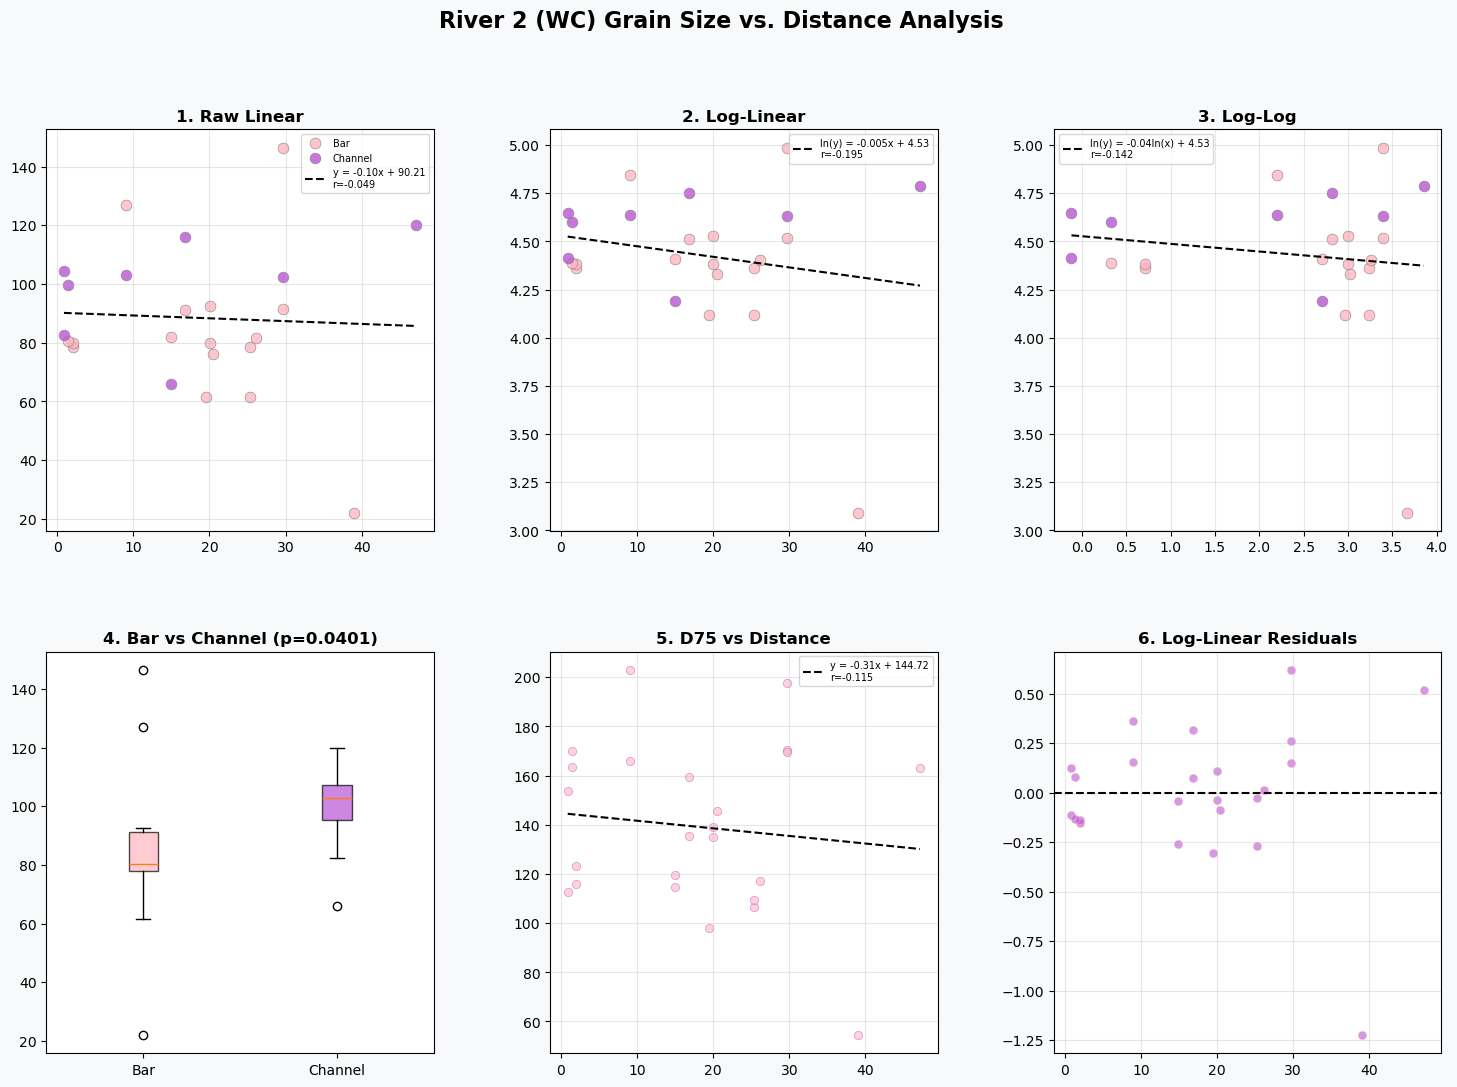

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.gridspec as gridspec
import warnings; warnings.filterwarnings('ignore')

file_path = 'Carolina_Rivers_Data_UPDATED.csv'df = pd.read_csv(file_path)
df.columns = df.columns.str.strip()

dist = df['Distance along river (km)'].values
med  = df['Median_Siz'].values
d75  = df['D75'].values
ln_med = np.log(med)
ln_dist = np.log(dist)
bar_mask = df['Type'] == 'Bar'
ch_mask = df['Type'] == 'Channel'

site_avg = df.groupby('Site_Name').agg(
    dist=('Distance along river (km)', 'mean'),
    med=('Median_Siz', 'mean'),
    type=('Type', 'first')
).reset_index()

slope, intercept, r_val, pval, se = stats.linregress(dist, med)
sl2, it2, rv2, pv2, se2 = stats.linregress(dist, ln_med)
sl3, it3, rv3, pv3, se3 = stats.linregress(ln_dist, ln_med)
bar_d = df[bar_mask]['Median_Siz'].values
ch_d  = df[ch_mask]['Median_Siz'].values
u, p_mw = stats.mannwhitneyu(bar_d, ch_d, alternative='two-sided')
sorting = d75 / med

fig = plt.figure(figsize=(18, 12))
fig.patch.set_facecolor('#f8f9fa')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.3, wspace=0.3)
colors = {'Bar': 'lightpink', 'Channel': 'mediumorchid'}
xx = np.linspace(dist.min(), dist.max(), 100)

ax1 = fig.add_subplot(gs[0, 0]); ax1.set_facecolor('white')
for t, c in colors.items():
    m = df['Type'] == t
    ax1.scatter(dist[m], med[m], color=c, label=t, alpha=0.8, s=60, edgecolors='grey', linewidth=0.5)
formula1 = f'y = {slope:.2f}x + {intercept:.2f}'
ax1.plot(xx, slope*xx+intercept, 'k--', label=f'{formula1}\nr={r_val:.3f}')
ax1.set_title('1. Raw Linear', fontweight='bold'); ax1.legend(fontsize=7); ax1.grid(alpha=0.3)

# Log-linear
ax2 = fig.add_subplot(gs[0, 1]); ax2.set_facecolor('white')
for t, c in colors.items():
    m = df['Type'] == t
    ax2.scatter(dist[m], ln_med[m], color=c, alpha=0.8, s=60, edgecolors='grey', linewidth=0.5)
formula2 = f'ln(y) = {sl2:.3f}x + {it2:.2f}'
ax2.plot(xx, sl2*xx+it2, 'k--', label=f'{formula2}\nr={rv2:.3f}')
ax2.set_title('2. Log-Linear', fontweight='bold'); ax2.grid(alpha=0.3); ax2.legend(fontsize=7)

# Log-log
ax3 = fig.add_subplot(gs[0, 2]); ax3.set_facecolor('white')
for t, c in colors.items():
    m = df['Type'] == t
    ax3.scatter(ln_dist[m], ln_med[m], color=c, alpha=0.8, s=60, edgecolors='grey', linewidth=0.5)
xxl = np.linspace(ln_dist.min(), ln_dist.max(), 100)
formula3 = f'ln(y) = {sl3:.2f}ln(x) + {it3:.2f}'
ax3.plot(xxl, sl3*xxl+it3, 'k--', label=f'{formula3}\nr={rv3:.3f}')
ax3.set_title('3. Log-Log', fontweight='bold'); ax3.grid(alpha=0.3); ax3.legend(fontsize=7)

# Boxplot
ax4 = fig.add_subplot(gs[1, 0]); ax4.set_facecolor('white')
bp = ax4.boxplot([bar_d, ch_d], labels=['Bar', 'Channel'], patch_artist=True)
for patch, color in zip(bp['boxes'], colors.values()):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax4.set_title(f'4. Bar vs Channel (p={p_mw:.4f})', fontweight='bold')

# D75 vs distance
ax5 = fig.add_subplot(gs[1, 1]); ax5.set_facecolor('white')
ax5.scatter(dist, d75, color='lightpink', alpha=0.6, edgecolors='mediumorchid', linewidth=0.5)
sl5, it5, r5, _, _ = stats.linregress(dist, d75)
formula5 = f'y = {sl5:.2f}x + {it5:.2f}'
ax5.plot(xx, sl5*xx+it5, 'k--', label=f'{formula5}\nr={r5:.3f}')
ax5.set_title('5. D75 vs Distance', fontweight='bold'); ax5.grid(alpha=0.3); ax5.legend(fontsize=7)

# Residuals
ax6 = fig.add_subplot(gs[1, 2]); ax6.set_facecolor('white')
fitted = sl2*dist + it2; resid = ln_med - fitted
ax6.scatter(dist, resid, color='mediumorchid', alpha=0.6, edgecolors='lightpink', linewidth=0.5)
ax6.axhline(0, color='black', linestyle='--')
ax6.set_title('6. Log-Linear Residuals', fontweight='bold'); ax6.grid(alpha=0.3)

plt.suptitle('River 2 (WC) Grain Size vs. Distance Analysis', fontsize=16, fontweight='bold', y=0.98)

plt.show()

**These plots are for River 1 (the river with site ID's starting with LR):**

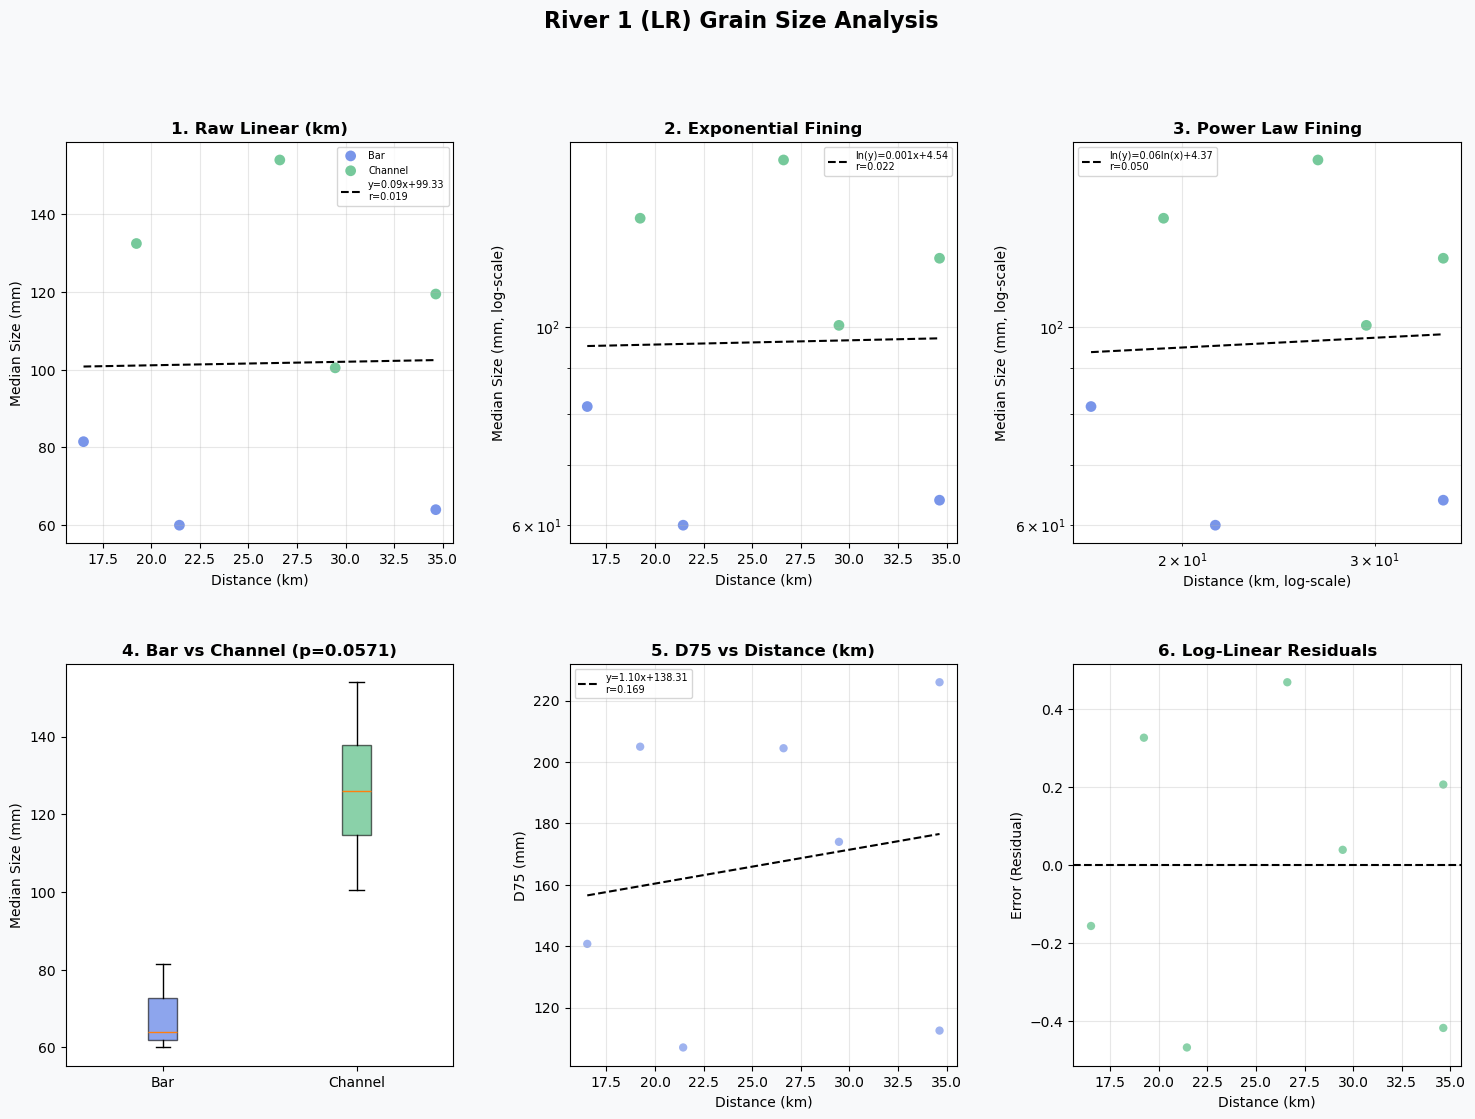

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.gridspec as gridspec
import warnings; warnings.filterwarnings('ignore')

file_path = r'C:\Users\alisa\Downloads\Earth_Forces\Carolina_1Rivers_Data_UPDATED.csv'
df = pd.read_csv(file_path)
df.columns = df.columns.str.strip()

# Filter out "None" types to ensure Bar vs Channel comparison remains clean
df = df[df['Type'].isin(['Bar', 'Channel'])]

dist = df['Distance along river (m)'].values 
med  = df['Median_Siz'].values
d75  = df['D75'].values

ln_med = np.log(med)
ln_dist = np.log(dist + 0.001) 

bar_mask = df['Type'] == 'Bar'
ch_mask = df['Type'] == 'Channel'

slope, intercept, r_val, pval, se = stats.linregress(dist, med)
sl2, it2, rv2, pv2, se2 = stats.linregress(dist, ln_med)
sl3, it3, rv3, pv3, se3 = stats.linregress(ln_dist, ln_med)
bar_d = df[bar_mask]['Median_Siz'].values
ch_d  = df[ch_mask]['Median_Siz'].values
u, p_mw = stats.mannwhitneyu(bar_d, ch_d, alternative='two-sided')

fig = plt.figure(figsize=(18, 12))
fig.patch.set_facecolor('#f8f9fa')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.3, wspace=0.3)
colors = {'Bar': 'royalblue', 'Channel': 'mediumseagreen'}
xx = np.linspace(dist.min(), dist.max(), 100)

# Raw linear
ax1 = fig.add_subplot(gs[0, 0]); ax1.set_facecolor('white')
for t, c in colors.items():
    m = df['Type'] == t
    ax1.scatter(dist[m], med[m], color=c, label=t, alpha=0.7, s=60, edgecolors='none')
ax1.plot(xx, slope*xx+intercept, 'k--', label=f'y={slope:.2f}x+{intercept:.2f}\nr={r_val:.3f}')
ax1.set_title('1. Raw Linear (km)', fontweight='bold'); ax1.legend(fontsize=7); ax1.grid(alpha=0.3)
ax1.set_xlabel('Distance (km)'); ax1.set_ylabel('Median Size (mm)')

# Log-linear (Sternberg)
ax2 = fig.add_subplot(gs[0, 1]); ax2.set_facecolor('white')
for t, c in colors.items():
    m = df['Type'] == t
    ax2.scatter(dist[m], med[m], color=c, alpha=0.7, s=60, edgecolors='none')
ax2.plot(xx, np.exp(sl2*xx+it2), 'k--', label=f'ln(y)={sl2:.3f}x+{it2:.2f}\nr={rv2:.3f}')
ax2.set_yscale('log')
ax2.set_title('2. Exponential Fining', fontweight='bold'); ax2.grid(alpha=0.3, which='both'); ax2.legend(fontsize=7)
ax2.set_xlabel('Distance (km)'); ax2.set_ylabel('Median Size (mm, log-scale)')

# Log-log 
ax3 = fig.add_subplot(gs[0, 2]); ax3.set_facecolor('white')
for t, c in colors.items():
    m = df['Type'] == t
    ax3.scatter(dist[m], med[m], color=c, alpha=0.7, s=60, edgecolors='none')
xx_log = np.logspace(np.log10(dist.min()+0.001), np.log10(dist.max()), 100)
ax3.plot(xx_log, np.exp(sl3*np.log(xx_log)+it3), 'k--', label=f'ln(y)={sl3:.2f}ln(x)+{it3:.2f}\nr={rv3:.3f}')
ax3.set_xscale('log'); ax3.set_yscale('log')
ax3.set_title('3. Power Law Fining', fontweight='bold'); ax3.grid(alpha=0.3, which='both'); ax3.legend(fontsize=7)
ax3.set_xlabel('Distance (km, log-scale)'); ax3.set_ylabel('Median Size (mm, log-scale)')

# Boxplot
ax4 = fig.add_subplot(gs[1, 0]); ax4.set_facecolor('white')
bp = ax4.boxplot([bar_d, ch_d], labels=['Bar', 'Channel'], patch_artist=True)
for patch, color in zip(bp['boxes'], colors.values()):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax4.set_title(f'4. Bar vs Channel (p={p_mw:.4f})', fontweight='bold')
ax4.set_ylabel('Median Size (mm)')

# D75 vs distance
ax5 = fig.add_subplot(gs[1, 1]); ax5.set_facecolor('white')
ax5.scatter(dist, d75, color='royalblue', alpha=0.5, edgecolors='none')
sl5, it5, r5, _, _ = stats.linregress(dist, d75)
ax5.plot(xx, sl5*xx+it5, 'k--', label=f'y={sl5:.2f}x+{it5:.2f}\nr={r5:.3f}')
ax5.set_title('5. D75 vs Distance (km)', fontweight='bold'); ax5.grid(alpha=0.3); ax5.legend(fontsize=7)
ax5.set_xlabel('Distance (km)'); ax5.set_ylabel('D75 (mm)')

# Residuals
ax6 = fig.add_subplot(gs[1, 2]); ax6.set_facecolor('white')
fitted = sl2*dist + it2; resid = ln_med - fitted
ax6.scatter(dist, resid, color='mediumseagreen', alpha=0.6, edgecolors='none')
ax6.axhline(0, color='black', linestyle='--')
ax6.set_title('6. Log-Linear Residuals', fontweight='bold'); ax6.grid(alpha=0.3)
ax6.set_xlabel('Distance (km)'); ax6.set_ylabel('Error (Residual)')

plt.suptitle('River 1 (LR) Grain Size Analysis', fontsize=16, fontweight='bold', y=0.99)
plt.show()

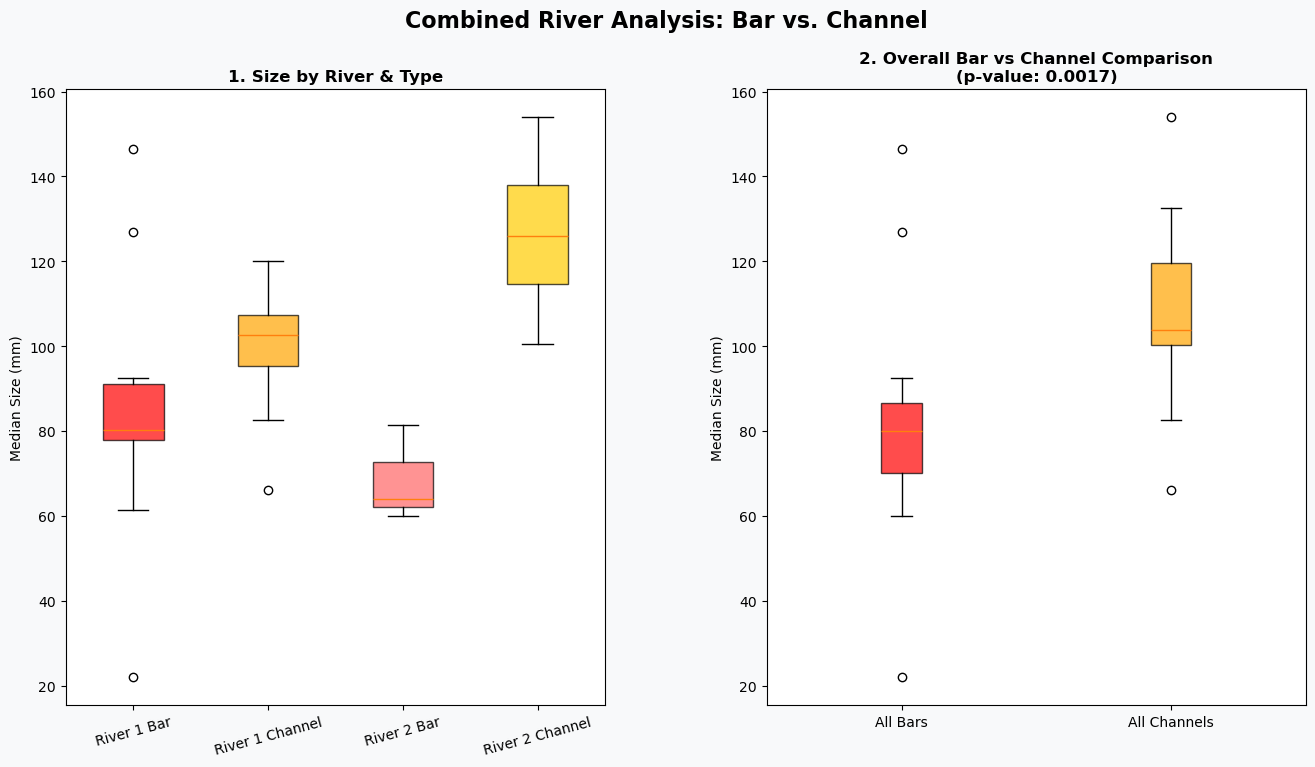

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.gridspec as gridspec
import warnings; warnings.filterwarnings('ignore')

path1 = r'C:\Users\alisa\Downloads\Earth_Forces\Carolina_Rivers_Data_UPDATED.csv'
df1 = pd.read_csv(path1)
df1.columns = df1.columns.str.strip()
df1 = df1[df1['Type'].isin(['Bar', 'Channel'])]
df1['River'] = 'River 1'
df1.rename(columns={'Distance along river (km)': 'dist_km'}, inplace=True)

path2 = r'C:\Users\alisa\Downloads\Earth_Forces\Carolina_1Rivers_Data_UPDATED.csv'
df2 = pd.read_csv(path2)
df2.columns = df2.columns.str.strip()
df2 = df2[df2['Type'].isin(['Bar', 'Channel'])]
df2['River'] = 'River 2'
df2.rename(columns={'Distance along river (m)': 'dist_km'}, inplace=True)

df_all = pd.concat([df1, df2], ignore_index=True)

fig = plt.figure(figsize=(16, 8))
fig.patch.set_facecolor('#f8f9fa')
gs = gridspec.GridSpec(1, 2, figure=fig, wspace=0.3)

ax1 = fig.add_subplot(gs[0, 0]); ax1.set_facecolor('white')
df_all['Group'] = df_all['River'] + " " + df_all['Type']
groups = ['River 1 Bar', 'River 1 Channel', 'River 2 Bar', 'River 2 Channel']
data_to_plot_grouped = [df_all[df_all['Group'] == g]['Median_Siz'] for g in groups]
bp1 = ax1.boxplot(data_to_plot_grouped, labels=groups, patch_artist=True)
box_colors1 = ['red', 'orange', '#ff6666', '#ffcc00']
for patch, color in zip(bp1['boxes'], box_colors1):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax1.set_title('1. Size by River & Type', fontweight='bold')
ax1.set_ylabel('Median Size (mm)')
plt.setp(ax1.get_xticklabels(), rotation=15)

ax2 = fig.add_subplot(gs[0, 1]); ax2.set_facecolor('white')
bar_combined = df_all[df_all['Type'] == 'Bar']['Median_Siz']
ch_combined  = df_all[df_all['Type'] == 'Channel']['Median_Siz']
u_comb, p_comb = stats.mannwhitneyu(bar_combined, ch_combined, alternative='two-sided')
bp2 = ax2.boxplot([bar_combined, ch_combined], labels=['All Bars', 'All Channels'], patch_artist=True)
box_colors2 = ['red', 'orange']
for patch, color in zip(bp2['boxes'], box_colors2):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax2.set_title(f'2. Overall Bar vs Channel Comparison\n(p-value: {p_comb:.4f})', fontweight='bold')
ax2.set_ylabel('Median Size (mm)')

plt.suptitle('Combined River Analysis: Bar vs. Channel', fontsize=16, fontweight='bold', y=0.98)
plt.show()